<a href="https://colab.research.google.com/github/Jo-ohnny/CI345_ML/blob/main/Lab9_Using_decison_Tree_finished_By_Jean.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

## lab 8 - knn classification for Video data

## Date : 5/6/2026

Name : Jean Oussou



# Step 1: Loading and Analyze Data

In [2]:
from google.colab import drive
import pandas as pd

#Mount Google Drive
drive.mount('/content/drive')

# Path to your CSV in Drive
video_store_file = '/content/drive/MyDrive/CI345_ML/data/Video_Store.csv'

orginal_vtable = pd.read_csv(video_store_file)
orginal_vtable.head(3)

Mounted at /content/drive


,Cust ID,Gender,Income,Age,Rentals,AvgPerVisit,Genre,Like
0,1,M,45000,25,32,2.5,Action,Yes
1,2,F,54000,33,12,3.4,Drama,No
2,3,F,32000,20,42,1.6,Comedy,No


In [3]:
df = orginal_vtable.head(3)
print(df.shape)





(3, 8)


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Cust ID      3 non-null      int64  
 1   Gender       3 non-null      object 
 2   Income       3 non-null      int64  
 3   Age          3 non-null      int64  
 4   Rentals      3 non-null      int64  
 5   AvgPerVisit  3 non-null      float64
 6   Genre        3 non-null      object 
 7   Like         3 non-null      object 
dtypes: float64(1), int64(4), object(3)
memory usage: 324.0+ bytes


In [5]:
df.dtypes

,0
Cust ID,int64
Gender,object
Income,int64
Age,int64
Rentals,int64
AvgPerVisit,float64
Genre,object
Like,object


In [6]:
df.isnull().sum()

,0
Cust ID,0
Gender,0
Income,0
Age,0
Rentals,0
AvgPerVisit,0
Genre,0
Like,0


In [7]:
vtable = orginal_vtable
vtable['Income'] = vtable['Income'].astype(float)
print(vtable.dtypes)
orginal_vtable.dtypes

Cust ID          int64
Gender          object
Income         float64
Age              int64
Rentals          int64
AvgPerVisit    float64
Genre           object
Like            object
dtype: object


,0
Cust ID,int64
Gender,object
Income,float64
Age,int64
Rentals,int64
AvgPerVisit,float64
Genre,object
Like,object


In [8]:
print(df['Income'].describe())
print(df.Income.describe())
print('------------------------')
df[['Income', 'Age', 'Rentals']].describe()

count        3.000000
mean     43666.666667
std      11060.440015
min      32000.000000
25%      38500.000000
50%      45000.000000
75%      49500.000000
max      54000.000000
Name: Income, dtype: float64
count        3.000000
mean     43666.666667
std      11060.440015
min      32000.000000
25%      38500.000000
50%      45000.000000
75%      49500.000000
max      54000.000000
Name: Income, dtype: float64
------------------------


,Income,Age,Rentals
count,3.000000,3.000000,3.000000
mean,43666.666667,26.000000,28.666667
std,11060.440015,6.557439,15.275252
min,32000.000000,20.000000,12.000000
25%,38500.000000,22.500000,22.000000
50%,45000.000000,25.000000,32.000000
75%,49500.000000,29.000000,37.000000
max,54000.000000,33.000000,42.000000


In [9]:
df = orginal_vtable
df.head(3)

,Cust ID,Gender,Income,Age,Rentals,AvgPerVisit,Genre,Like
0,1,M,45000.0,25,32,2.5,Action,Yes
1,2,F,54000.0,33,12,3.4,Drama,No
2,3,F,32000.0,20,42,1.6,Comedy,No


## Step 2: Data Analyzation

Genre
Drama     20
Action    18
Comedy    12
Name: count, dtype: int64


<Axes: title={'center': 'Number in Like'}, xlabel='Genre'>

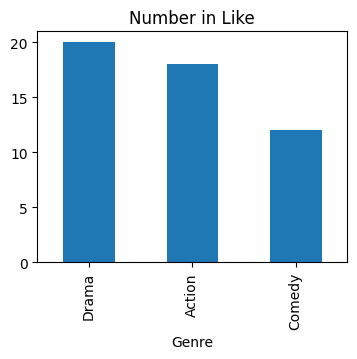

In [10]:
res = df.Genre.value_counts()
#res = df[Genre].value_counts()
print(res)
res.plot(kind='bar', title="Number in Like", figsize=(4,3))

<Axes: title={'center': 'Income'}, ylabel='Frequency'>

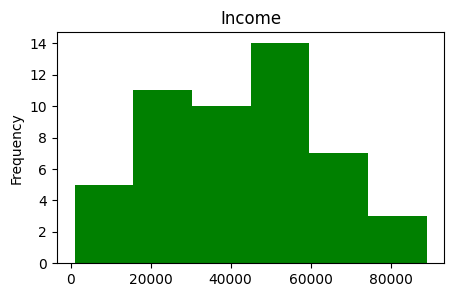

In [11]:
df = orginal_vtable
res = df['Income']
res.plot(kind = 'hist' , bins = 6, title = 'Income', color='green', figsize= (5,3))


In [12]:
res = df['Genre'].value_counts()



Lab 08 Finished by Jean


array([[<Axes: title={'center': 'Income'}>,
        <Axes: title={'center': 'Age'}>],
       [<Axes: title={'center': 'Rentals'}>,
        <Axes: title={'center': 'AvgPerVisit'}>]], dtype=object)

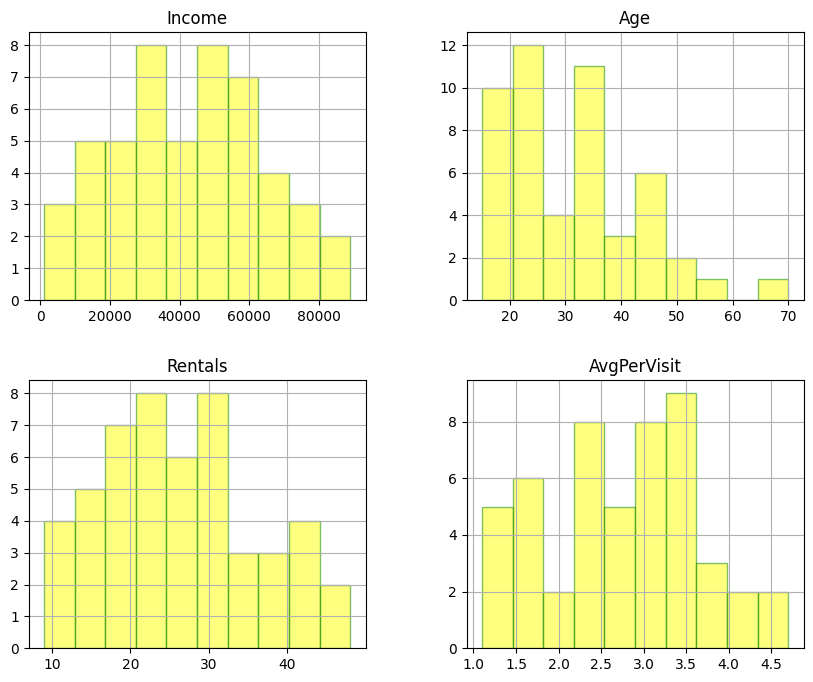

In [13]:
df = orginal_vtable
print('Lab 08 Finished by Jean')
res = df[['Income', 'Age', 'Rentals', 'AvgPerVisit']]
res
res.hist(alpha = 0.5, edgecolor='green', color = 'yellow', figsize= (10,8))


In [14]:
res = df['Like'].value_counts()



#Step 3:Data Processomg
### Convert categorical feature to numerical feature



# Method 1 : Using LabelEncoder

In [15]:
df=orginal_vtable
print(df.shape)
df.head(2)

(50, 8)


,Cust ID,Gender,Income,Age,Rentals,AvgPerVisit,Genre,Like
0,1,M,45000.0,25,32,2.5,Action,Yes
1,2,F,54000.0,33,12,3.4,Drama,No


In [16]:

# Problem: model may think numbers have order (0 < 1 < 2)
# Use mainly for target labels (y), not features

from sklearn.preprocessing import LabelEncoder

# All category features are transfered to numeric feature
encoder = LabelEncoder()
df= df.apply(encoder.fit_transform)
print(df.dtypes)
df.head(2)

# vs Method
le = LabelEncoder()
df = orginal_vtable
df['Gender'] = le.fit_transform(df['Gender'])
df['Genre'] = le.fit_transform(df['Genre'])
df['Like'] = le.fit_transform(df['Like'])


print(df.dtypes)
df.head(2)

Cust ID        int64
Gender         int64
Income         int64
Age            int64
Rentals        int64
AvgPerVisit    int64
Genre          int64
Like           int64
dtype: object
Cust ID          int64
Gender           int64
Income         float64
Age              int64
Rentals          int64
AvgPerVisit    float64
Genre            int64
Like             int64
dtype: object


,Cust ID,Gender,Income,Age,Rentals,AvgPerVisit,Genre,Like
0,1,1,45000.0,25,32,2.5,0,1
1,2,0,54000.0,33,12,3.4,2,0


#Step 4 : KNN Classification

In [17]:
# Current process data has not category
vtable_after_LabelEncoder = df
# Seperate data part
v_data = vtable[['Gender','Income','Age','Rentals', 'AvgPerVisit','Genre']]
# Get target
v_target = vtable['Like']

print(v_data.shape)
print(v_target.shape)
v_data.head(3)

(50, 6)
(50,)


,Gender,Income,Age,Rentals,AvgPerVisit,Genre
0,1,45000.0,25,32,2.5,0
1,0,54000.0,33,12,3.4,2
2,0,32000.0,20,42,1.6,1


In [18]:
# Step 3: Split Dataset
from sklearn.model_selection import train_test_split

data_train, data_test, target_train, target_test  = train_test_split (v_data, v_target, random_state = 11, test_size = 0.2)

# What is the output
print(data_train.shape)
print(data_test.shape)

print(target_train.shape)
print(target_test.shape)

# Step 4: Create a KNN classifier
from sklearn.neighbors import KNeighborsClassifier

n_neighbors = 3
knn_classifier = KNeighborsClassifier(n_neighbors, weights = 'distance')
print(knn_classifier)

#Training the KNN classifier
knn_classifier.fit (X = data_train, y = target_train)
#print(knn_classifier)

# Step 5: Testing
predicted = knn_classifier.predict(X= data_test)

# Step 6: Evaluation
# Classification report
from sklearn.metrics import classification_report
report = classification_report(target_test, predicted)
print(report)

#Use Confusion_matrix
from sklearn.metrics import confusion_matrix
matrix = confusion_matrix(y_true = target_test, y_pred = predicted)
print('------ Confusion Matrix')
print(matrix)

(40, 6)
(10, 6)
(40,)
(10,)
KNeighborsClassifier(n_neighbors=3, weights='distance')
              precision    recall  f1-score   support

           0       1.00      0.43      0.60         7
           1       0.43      1.00      0.60         3

    accuracy                           0.60        10
   macro avg       0.71      0.71      0.60        10
weighted avg       0.83      0.60      0.60        10

------ Confusion Matrix
[[3 4]
 [0 3]]


#Step 5 : Converting categoric feature to numerical feature






# Method 2 : Using get_dummies -

In [19]:
# Data Processomg
# Convert Converting categoric feature to numerical feature

# Method 2 : Using get_dummies
df = orginal_vtable
print(df.head(2))
gender_df= pd.get_dummies(df['Gender'])

v_matrix = pd.get_dummies(orginal_vtable)
print(v_matrix.dtypes)
print(v_matrix.head(2))

v_matrix = v_matrix.astype(int)
v_matrix.head(2)

# Problem : numberical features also changed !!!!


   Cust ID  Gender   Income  Age  Rentals  AvgPerVisit  Genre  Like
0        1       1  45000.0   25       32          2.5      0     1
1        2       0  54000.0   33       12          3.4      2     0
Cust ID          int64
Gender           int64
Income         float64
Age              int64
Rentals          int64
AvgPerVisit    float64
Genre            int64
Like             int64
dtype: object
   Cust ID  Gender   Income  Age  Rentals  AvgPerVisit  Genre  Like
0        1       1  45000.0   25       32          2.5      0     1
1        2       0  54000.0   33       12          3.4      2     0


,Cust ID,Gender,Income,Age,Rentals,AvgPerVisit,Genre,Like
0,1,1,45000,25,32,2,0,1
1,2,0,54000,33,12,3,2,0


In [20]:
from pandas.core.arrays import categorical

# Convert Converting categoric feature to numerical feature

# Method 2 : Using get_dummies -
df = orginal_vtable
categorical_cols = ['Gender', 'Genre', 'Like']
df_use_dummies = pd.get_dummies(df, columns = categorical_cols, dtype=int)

# Drop duplicated columns

print('---------------')
print(df_use_dummies.shape)
df_use_dummies.head(2)


---------------
(50, 12)


,Cust ID,Income,Age,Rentals,AvgPerVisit,Gender_0,Gender_1,Genre_0,Genre_1,Genre_2,Like_0,Like_1
0,1,45000.0,25,32,2.5,0,1,1,0,0,0,1
1,2,54000.0,33,12,3.4,1,0,0,0,1,1,0


In [21]:
df_use_dummies.shape

(50, 12)

In [22]:
# Current process data has not category
vtable= df_use_dummies
# Seperate data part
v_data = vtable[['Income','Age','Rentals', 'AvgPerVisit', 'Gender_0', 'Gender_1', 'Genre_0', 'Genre_1', 'Genre_2']]
# Get target
v_target = vtable['Like_1']


print(v_data.shape)
print(v_target.shape)
v_data.head(2)

(50, 9)
(50,)


,Income,Age,Rentals,AvgPerVisit,Gender_0,Gender_1,Genre_0,Genre_1,Genre_2
0,45000.0,25,32,2.5,0,1,1,0,0
1,54000.0,33,12,3.4,1,0,0,0,1


#Step 6: KNN Classificaton

In [23]:
# Seperate data and target, after use dummies

# Define all_cols from the vtable DataFrame's columns
all_cols = vtable.columns.tolist()
print(all_cols)

size = len(all_cols)
#print(size)

# Define data_cols, excluding 'Cust ID' and the 'Like' dummy variables
data_cols = [col for col in all_cols if col not in ['Cust ID', 'Like_0', 'Like_1']]
print(data_cols)

# Seperate data part
v_data = vtable[data_cols]
# Get target
v_target = vtable['Like_1']


print(v_data.shape)
print(v_target.shape)


['Cust ID', 'Income', 'Age', 'Rentals', 'AvgPerVisit', 'Gender_0', 'Gender_1', 'Genre_0', 'Genre_1', 'Genre_2', 'Like_0', 'Like_1']
['Income', 'Age', 'Rentals', 'AvgPerVisit', 'Gender_0', 'Gender_1', 'Genre_0', 'Genre_1', 'Genre_2']
(50, 9)
(50,)


In [24]:
v_data.head(2)

,Income,Age,Rentals,AvgPerVisit,Gender_0,Gender_1,Genre_0,Genre_1,Genre_2
0,45000.0,25,32,2.5,0,1,1,0,0
1,54000.0,33,12,3.4,1,0,0,0,1


In [25]:
v_target.head(2)

,Like_1
0,1
1,0


In [26]:
data_train.describe()

,Gender,Income,Age,Rentals,AvgPerVisit,Genre
count,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000
mean,0.525000,42075.000000,31.800000,26.725000,2.812500,1.025000
std,0.505736,20391.536077,12.002564,9.771721,0.867708,0.919518
min,0.000000,1000.000000,16.000000,11.000000,1.400000,0.000000
25%,0.000000,25750.000000,23.500000,19.000000,2.200000,0.000000
50%,1.000000,43000.000000,30.000000,25.500000,2.850000,1.000000
75%,1.000000,56000.000000,35.250000,32.250000,3.325000,2.000000
max,1.000000,83000.000000,70.000000,48.000000,4.700000,2.000000


In [27]:
# After using use_dummies

# Step 3: Split Dataset
from sklearn.model_selection import train_test_split

data_train, data_test, target_train, target_test  = train_test_split (v_data, v_target, random_state = 11, test_size = 0.2)

# What is the output
print(data_train.shape)
print(data_test.shape)

print(target_train.shape)
print(target_test.shape)

# Step 4: Create a KNN classifier
from sklearn.neighbors import KNeighborsClassifier
n_neighbors = 3
knn_classifier = KNeighborsClassifier(n_neighbors, weights = 'distance')
print(knn_classifier)

#Training the KNN classifier
knn_classifier.fit (X = data_train, y = target_train)
#print(knn_classifier)

# Step 5: Testing
predicted = knn_classifier.predict(X= data_test)

# Step 6: Evaluation
# Classification report
from sklearn.metrics import classification_report
report = classification_report(target_test, predicted)
print(report)

#Use Confusion_matrix
from sklearn.metrics import confusion_matrix
matrix = confusion_matrix(y_true = target_test, y_pred = predicted)
print('------ Confusion Matrix')
print(matrix)

(40, 9)
(10, 9)
(40,)
(10,)
KNeighborsClassifier(n_neighbors=3, weights='distance')
              precision    recall  f1-score   support

           0       1.00      0.43      0.60         7
           1       0.43      1.00      0.60         3

    accuracy                           0.60        10
   macro avg       0.71      0.71      0.60        10
weighted avg       0.83      0.60      0.60        10

------ Confusion Matrix
[[3 4]
 [0 3]]


#Lab 09 Using decison Tree

##Convert categorical features use dummies

In [30]:

# What is the output
print(data_train.shape)
print(data_test.shape)

print(target_train.shape)
print(target_test.shape)
data_train.head(2)



(40, 9)
(10, 9)
(40,)
(10,)


,Income,Age,Rentals,AvgPerVisit,Gender_0,Gender_1,Genre_0,Genre_1,Genre_2
14,68000.0,30,36,2.7,0,1,0,1,0
42,49000.0,28,48,3.3,1,0,0,0,1


#Apply decision classifier


In [31]:
#Step 4 : Create decison tree
from sklearn import tree
dt_classifier = tree.DecisionTreeClassifier()

#traning the decision classifier
dt_classifier.fit(X = data_train, y = target_train)
print(dt_classifier)

#dt_classifier.plot

#step 5: testing
predicted = dt_classifier.predict(X = data_test)

#step 6: evaluation , classification report
from sklearn.metrics import classification_report
report = classification_report(target_test, predicted)
print(report)

#use confusion_matrix
from sklearn.metrics import confusion_matrix
matrix = confusion_matrix(y_true = target_test, y_pred = predicted)
print('--------- Confusion Matrix')
print(matrix)

DecisionTreeClassifier()
              precision    recall  f1-score   support

           0       0.83      0.71      0.77         7
           1       0.50      0.67      0.57         3

    accuracy                           0.70        10
   macro avg       0.67      0.69      0.67        10
weighted avg       0.73      0.70      0.71        10

--------- Confusion Matrix
[[5 2]
 [1 2]]


In [32]:
#use scores method
score = knn_classifier.score(data_test, target_test)
score

0.6

In [ ]:
#Use Confusion_matrix
from sklearn.metrics import confusion_matrix
matrix = confusion_matrix(y_true = target_test, y_pred = predicted)
print(matrix)

In [ ]:
#Classification report
from sklearn.metrics import classification_report
report = classification_report(target_test, predicted)
print(report)